# Clustering Music Genres

The goal is to group songs by their audio characteristics (tempo, energy, danceability, loudness, acousticness and others) so that songs with a similar sound end up together. The dataset lists the 1,994 most popular songs on Spotify with their audio features and a top genre (`Spotify-2000.csv`).

Reference solution: [Clustering Music Genres with Machine Learning](https://amanxai.com/2022/04/05/clustering-music-genres-with-machine-learning/) (Aman Kharwal). Dataset: the Kaggle [Spotify - All Time Top 2000s Mega Dataset](https://www.kaggle.com/datasets/iamsumat/spotify-top-2000s-mega-dataset), here downloaded from a GitHub copy of the file.

The reference runs K-Means with 10 clusters on six of the features, without scaling, and never compares the clusters with the genres. This notebook checks that, and also tests whether the clusters relate to the genre column, which the clustering does not use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from yellowbrick.cluster import KElbowVisualizer

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Clustering/clustering_music_genres')

## Data Loading

In [2]:
df = pd.read_csv("Spotify-2000.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Index                   1994 non-null   int64
 1   Title                   1994 non-null   str  
 2   Artist                  1994 non-null   str  
 3   Top Genre               1994 non-null   str  
 4   Year                    1994 non-null   int64
 5   Beats Per Minute (BPM)  1994 non-null   int64
 6   Energy                  1994 non-null   int64
 7   Danceability            1994 non-null   int64
 8   Loudness (dB)           1994 non-null   int64
 9   Liveness                1994 non-null   int64
 10  Valence                 1994 non-null   int64
 11  Length (Duration)       1994 non-null   str  
 12  Acousticness            1994 non-null   int64
 13  Speechiness             1994 non-null   int64
 14  Popularity              1994 non-null   int64
dtypes: int64(11), str(4)
memory usag

## Data Cleaning

`Length (Duration)` is stored as text (for example `"1,010"`, with a thousands separator), so it has to be converted to a number. `Index` is a row counter and is dropped. There are no null values or duplicated rows.

In [3]:
df["Length (Duration)"] = df["Length (Duration)"].str.replace(",", "").astype(int)
df = df.drop(columns="Index")
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Year,1994.0,1993.0,16.1,1956.0,1979.0,1993.0,2007.0,2019.0
Beats Per Minute (BPM),1994.0,120.2,28.0,37.0,99.0,119.0,136.0,206.0
Energy,1994.0,59.7,22.2,3.0,42.0,61.0,78.0,100.0
Danceability,1994.0,53.2,15.4,10.0,43.0,53.0,64.0,96.0
Loudness (dB),1994.0,-9.0,3.6,-27.0,-11.0,-8.0,-6.0,-2.0
Liveness,1994.0,19.0,16.7,2.0,9.0,12.0,23.0,99.0
Valence,1994.0,49.4,24.9,3.0,29.0,47.0,69.8,99.0
Length (Duration),1994.0,262.4,93.6,93.0,212.0,245.0,289.0,1412.0
Acousticness,1994.0,28.9,29.0,0.0,3.0,18.0,50.0,99.0
Speechiness,1994.0,5.0,4.4,2.0,3.0,4.0,5.0,55.0


## Exploratory Data Analysis

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

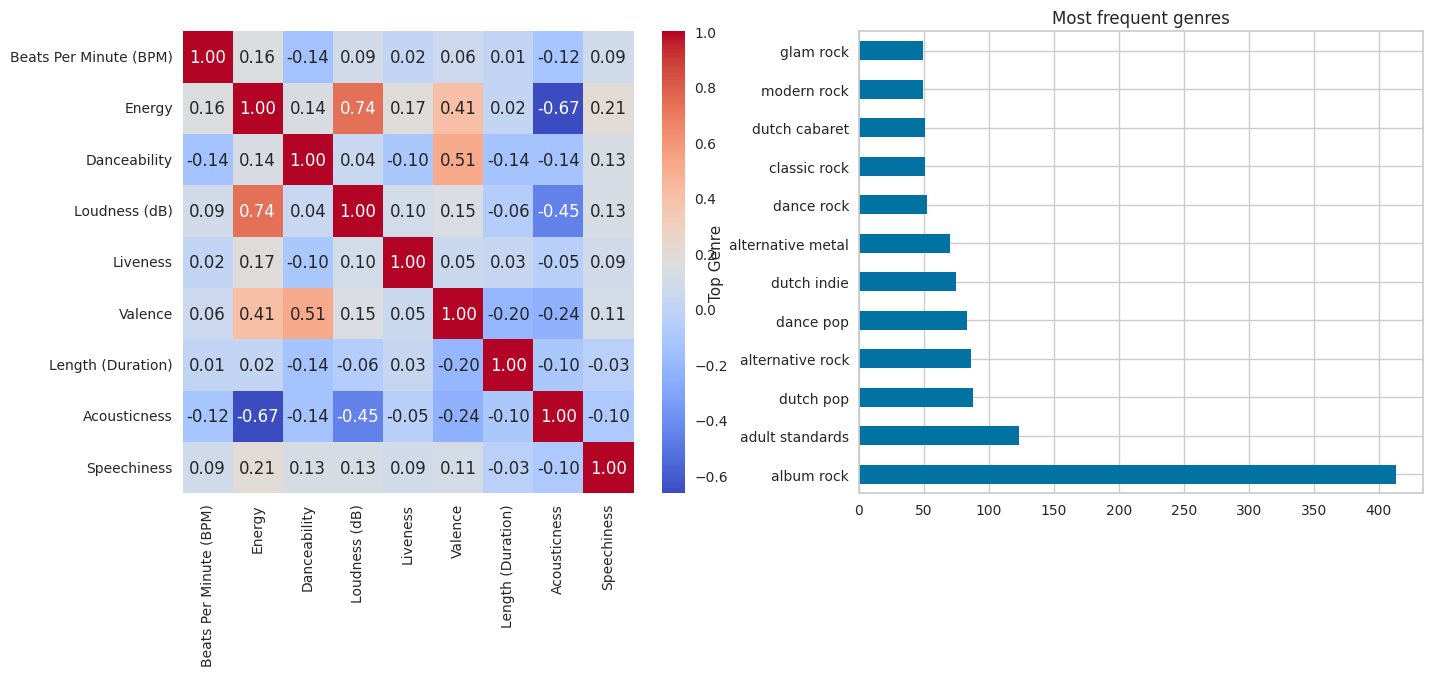

149

In [4]:
audio = ["Beats Per Minute (BPM)", "Energy", "Danceability", "Loudness (dB)", "Liveness", "Valence", "Length (Duration)", "Acousticness", "Speechiness"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df[audio].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
df["Top Genre"].value_counts().head(12).plot(kind="barh", ax=axes[1], title="Most frequent genres")
plt.show()
df["Top Genre"].nunique()

Energy, loudness and acousticness are strongly related (energy and loudness 0.74, energy and acousticness -0.67), and valence goes with danceability (0.51). The genre column has 149 different values, and `album rock` alone accounts for 413 of the 1,994 songs.

## Reference Check

The reference clusters six features (BPM, loudness, liveness, valence, acousticness, speechiness) with k = 10. It leaves out energy, danceability and length without saying why. Its scaling loop `for i in data.columns: MinMaxScaler(i)` never fits or applies a scaler, so K-Means works on raw values in which the tempo (37 to 206) and the length (in seconds, up to about 1,400) dominate the distances. Then the cluster numbers are renamed with `map({1: "Cluster 1", ..., 10: "Cluster 10"})`, but K-Means numbers its clusters from 0 to 9, so the songs of cluster 0 get no name at all.

In [5]:
ref_features = ["Beats Per Minute (BPM)", "Loudness (dB)", "Liveness", "Valence", "Acousticness", "Speechiness"]
ref_labels = KMeans(10, n_init=10, random_state=42).fit_predict(df[ref_features])

names = {i: f"Cluster {i}" for i in range(1, 11)}
renamed = pd.Series(ref_labels).map(names)
print("songs left without a cluster name after the reference's renaming:", renamed.isnull().sum(), "(size of cluster 0:", (ref_labels == 0).sum(), ")")
print("silhouette of the reference clustering:", round(silhouette_score(df[ref_features], ref_labels), 3))

songs left without a cluster name after the reference's renaming: 175 (size of cluster 0: 175 )
silhouette of the reference clustering: 0.24


## Feature Engineering

All nine audio features are used (`Year`, `Popularity` and the text columns are not audio characteristics) and standardized with the `StandardScaler`, so that no feature dominates because of its unit.

In [6]:
x = StandardScaler().fit_transform(df[audio])
x.shape

(1994, 9)

## Model Training

The number of clusters is chosen with the elbow method (`KElbowVisualizer`) and the silhouette score.

In [11]:
#pip install --upgrade yellowbrick

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

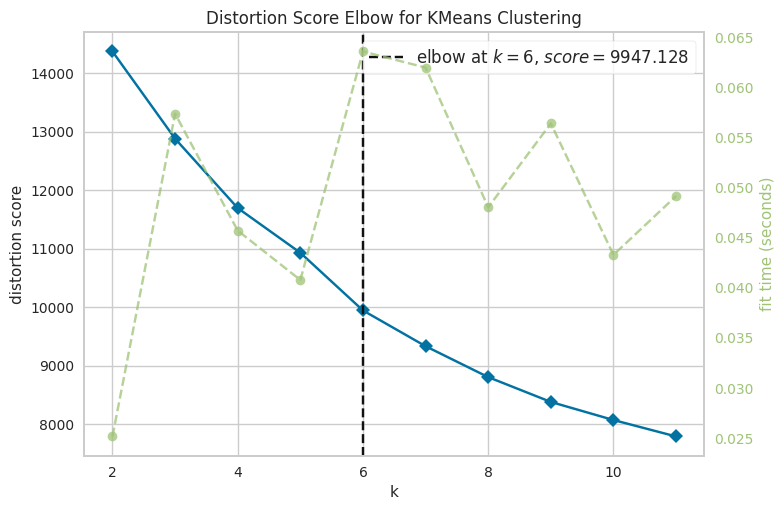

np.int64(6)

In [15]:
elbow = KElbowVisualizer(KMeans(n_init=10, random_state=42), k=(2, 12), force_model=True).fit(x)
elbow.show()
elbow.elbow_value_

In [16]:
silhouettes = {k: silhouette_score(x, KMeans(k, n_init=10, random_state=42).fit_predict(x)) for k in range(2, 13)}
pd.Series(silhouettes).round(3)

2     0.208
3     0.167
4     0.171
5     0.162
6     0.185
7     0.169
8     0.154
9     0.149
10    0.141
11    0.142
12    0.138
dtype: float64

The elbow method gives k = 6. The silhouette score is highest for k = 2 (0.208) and 0.185 for k = 6, and it is below 0.21 for every k: the audio features do not form clearly separated groups, songs vary along a continuum. The reference's k = 10 gives a silhouette of only 0.141 on the standardized features. k = 6 is used because of the elbow, and the profile below shows that the six clusters can be interpreted.

In [17]:
K = elbow.elbow_value_
df["cluster"] = KMeans(K, n_init=10, random_state=42).fit_predict(x)
df["cluster"].value_counts().sort_index()

cluster
0    128
1    517
2    647
3    550
4     90
5     62
Name: count, dtype: int64

## Evaluation

In [18]:
profile = df.groupby("cluster")[audio + ["Year", "Popularity"]].mean().round(0)
profile["songs"] = df["cluster"].value_counts().sort_index()
profile

,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Year,Popularity,songs
cluster,,,,,,,,,,,,
0,118.0,69.0,50.0,-8.0,69.0,56.0,254.0,28.0,6.0,1994.0,54.0,128
1,113.0,33.0,47.0,-12.0,14.0,32.0,248.0,62.0,4.0,1990.0,58.0,517
2,116.0,67.0,66.0,-9.0,15.0,73.0,240.0,20.0,4.0,1991.0,61.0,647
3,132.0,73.0,45.0,-7.0,17.0,38.0,259.0,10.0,5.0,1998.0,60.0,550
4,119.0,60.0,44.0,-10.0,18.0,36.0,546.0,22.0,5.0,1986.0,56.0,90
5,128.0,71.0,65.0,-7.0,19.0,63.0,252.0,19.0,24.0,1999.0,67.0,62


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

variance explained by 2 components: 0.454
PCA loadings:
                         PC1   PC2
Beats Per Minute (BPM)  0.12 -0.26
Energy                  0.57 -0.16
Danceability            0.22  0.62
Loudness (dB)           0.47 -0.23
Liveness                0.11 -0.22
Valence                 0.36  0.48
Length (Duration)      -0.04 -0.40
Acousticness           -0.47  0.17
Speechiness             0.19  0.04


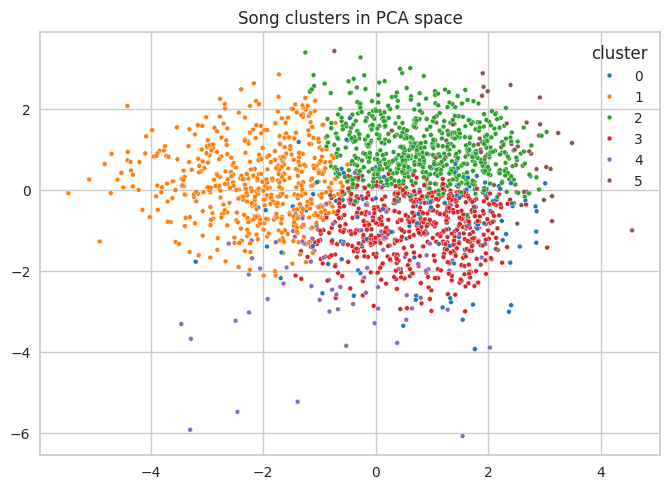

In [19]:
pca = PCA(2).fit(x)
components = pca.transform(x)
print("variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))
print("PCA loadings:")
print(pd.DataFrame(pca.components_, columns=audio, index=["PC1", "PC2"]).round(2).T)

sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df["cluster"], palette="tab10", s=12)
plt.title("Song clusters in PCA space")
plt.show()

The clusters do not use the genre column, so the genres can serve as an independent check. For the most frequent genres, the table shows which share of the songs of each genre falls into each cluster, and the normalized mutual information (found while researching how to compare a clustering with labels, not covered in class) measures how much the clusters and the genres agree, from 0 (independent) to 1 (identical), on the songs of the 8 most frequent genres.

In [20]:
top_genres = df["Top Genre"].value_counts().head(8).index
top = df[df["Top Genre"].isin(top_genres)]

print(pd.crosstab(top["cluster"], top["Top Genre"], normalize="columns").round(2))
print("NMI between clusters and genres:", round(normalized_mutual_info_score(top["Top Genre"], top["cluster"]), 3))

Top Genre  adult standards  album rock  alternative metal  alternative rock  \
cluster                                                                       
0                     0.07        0.05               0.04              0.08   
1                     0.53        0.22               0.14              0.17   
2                     0.33        0.38               0.14              0.23   
3                     0.06        0.21               0.60              0.51   
4                     0.01        0.13               0.06              0.00   
5                     0.01        0.02               0.01              0.00   

Top Genre  dance pop  dance rock  dutch indie  dutch pop  
cluster                                                   
0               0.05        0.13         0.05       0.07  
1               0.17        0.15         0.32       0.27  
2               0.41        0.50         0.39       0.30  
3               0.28        0.13         0.24       0.35  
4            

The six clusters describe types of sound:

- **Cluster 1, soft and acoustic (517 songs):** low energy (33), high acousticness (62), quiet (-12 dB). More than half of the `adult standards` songs (53%) are here.
- **Cluster 2, happy and danceable (647 songs):** high danceability (66) and valence (73), low acousticness. It holds 41% of `dance pop` and 50% of `dance rock`.
- **Cluster 3, loud and dark (550 songs):** high energy (73), loud (-7 dB), low valence (38), almost no acoustic sound (10) and a faster tempo (132 BPM). It holds 60% of `alternative metal` and 51% of `alternative rock`.
- **Cluster 0, live recordings (128 songs):** liveness of 69, against 14 to 19 in the other clusters.
- **Cluster 4, very long songs (90 songs):** an average duration of 546 seconds (about 9 minutes), against about 250 in the others.
- **Cluster 5, spoken and rap-like (62 songs):** speechiness of 24, against 4 to 6 elsewhere, together with a high danceability.

The clusters follow the sound, not the genre label: the normalized mutual information with the genres is only 0.071. A big genre such as `album rock` is spread over several clusters (22%, 38% and 21% of its songs are in clusters 1, 2 and 3), and the same cluster holds songs of very different genres. The reference title speaks of clustering music genres, but the audio features alone are not enough to recover the genres.

## Conclusion

**Reference approach.** The reference runs K-Means with k = 10 on six of the audio features (it drops energy, danceability and length without a reason), does not scale them (its scaling loop never applies a scaler), and does not choose k. Its renaming of the clusters maps the numbers 1 to 10, but K-Means labels its clusters 0 to 9, so the 175 songs of cluster 0 get no name at all and no cluster called "Cluster 10" exists. It shows a 3D plot and never checks the clusters against the genres.

**Our approach.** `Length (Duration)` was converted from text, and the nine audio features were standardized. The elbow method gives k = 6; the silhouette score is highest for k = 2 (0.208) and low for every k (below 0.21). The six clusters are interpretable as sound types:

| Cluster | Songs | Main characteristic |
|---|---|---|
| Soft and acoustic | 517 | energy 33, acousticness 62 |
| Happy and danceable | 647 | danceability 66, valence 73 |
| Loud and dark | 550 | energy 73, loudness -7 dB, valence 38 |
| Live recordings | 128 | liveness 69 |
| Very long songs | 90 | about 9 minutes |
| Spoken / rap-like | 62 | speechiness 24 |

**Genres.** The clusters relate to the genres only loosely (normalized mutual information 0.071 on the 8 most frequent genres). Some genres lean toward a cluster (60% of `alternative metal` in the loud and dark cluster, 53% of `adult standards` in the soft one), but most genres are spread over several clusters. Grouping songs by audio features finds sound types, not genres.

**Limitations.** The silhouette is low for every k, so the segments overlap and the number of clusters is a judgement (elbow 6, silhouette 2). Some clusters are small (62 to 128 songs) and are driven by a single feature (liveness, length, speechiness), so they mainly isolate unusual songs. The dataset contains only popular songs, and the 149 genre labels are very unevenly used.